Question: how does the difficulty of the training data affect the performance of the final model?

We have training data sorted into several difficulty levels:
d0.00 : very clear pipettes, near center of frame, focus always at 0
d0.20 : very clear pipettes, near center of frame, focus near 0
d0.40 : a little more background noise, pipettes farther from center, focus possibly wide
d0.60 : more noise, farther from center
d0.80 : very noisy, many examples difficult for a human
d1.00 : mostly impossible

Results:
- Training on harder datasets decreases performance on easier datasets. This is somewhat expected since harder datasets have more impossible examples

Conclusions:
- Update training data to exclude impossible examples, since these may be adding too much noise to training
- Train on a variety of difficulty levels for best results?

In [1]:
import os, shutil
from training import TrainingHistory, fit_model
from training import fit_model
# from training_data import TrainingData, Normalizer
import matplotlib.pyplot as plt

2023-10-25 12:13:38.622631: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-10-25 12:13:39.559219: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
save_path = "models/test_difficulty"
training_data_path = "training_data"

In [3]:
from training_data import load_training_data
training_data = load_training_data(training_data_path)
levels = list(training_data.levels.keys())
save_paths = {level:f"{save_path}/{level}" for level in levels}

In [6]:
# if os.path.exists(save_path):
#     shutil.rmtree(save_path)

for level in training_data.levels:
    fit_model(
        training_data=training_data_path,
        training_level=level,
        save_path=save_paths[level],
        model_type='ResNet101V2',
    )

GPUS: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')] False
Loaded 99500 training examples and 3000 validation examples


2023-09-05 16:41:39.564129: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21326 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:65:00.0, compute capability: 8.6


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet101v2 (Functional)    (None, 16, 16, 2048)      42626560  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 3)                 6147      
                                                                 
Total params: 42632707 (162.63 MB)
Trainable params: 6147 (24.01 KB)
Non-trainable params: 42626560 (162.61 MB)
_________________________________________________________________
None
Epoch 1/10


2023-09-05 16:42:06.792913: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2023-09-05 16:42:07.869442: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2023-09-05 16:42:08.863435: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x1fdde230 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2023-09-05 16:42:08.863479: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2023-09-05 16:42:08.875880: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2023-09-05 16:42:09.069554: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the proce


Batch 0


...

INFO:tensorflow:Assets written to: models/test_difficulty/d0.80/fit_model/assets


GPUS: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')] False
Loaded 99500 training examples and 3000 validation examples
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet101v2 (Functional)    (None, 16, 16, 2048)      42626560  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 3)                 6147      
                                                                 
Total params: 42632707 (162.63 MB)
Trainable params: 6147 (24.01 KB)
Non-trainable params: 42626560 (162.61 MB)
_________________________________________________________________
None
Epoch 1/10

Batch 0
saving weigts to models/test_difficulty/d1.0

 100/1554 [>.............................] - ETA: 10:02 - loss: 0.6742
Batch 100
    Training MSE (xyz, xy, z): 0.5684403681147377 0.6884011519196485 0.32851880050491655  Slopes: [-0.006130168430125646, -0.005330609848617256, -0.007729285593142424]
    Validation d0.00  MSE (xyz, xy, z): 0.12 0.131 0.0978  Slopes: -0.00728 -0.0111 0.000309
    Validation d0.20  MSE (xyz, xy, z): 0.147 0.185 0.0712  Slopes: -0.00615 -0.00898 -0.000494
    Validation d0.40  MSE (xyz, xy, z): 0.235 0.276 0.152  Slopes: -0.00651 -0.00876 -0.002
    Validation d0.60  MSE (xyz, xy, z): 0.378 0.431 0.273  Slopes: -0.00756 -0.00843 -0.0058
    Validation d0.80  MSE (xyz, xy, z): 0.487 0.571 0.318  Slopes: -0.00784 -0.00666 -0.0102
    Validation d1.00  MSE (xyz, xy, z): 0.58 0.701 0.339  Slopes: -0.00654 -0.0048 -0.01
 200/1554 [==>...........................] - ETA: 13:13 - loss: 0.6079
Batch 200
    Training MSE (xyz, xy, z): 0.5163106593958219 0.6371638178127339 0.27460434256199806  Slopes: [-0.003325732758

INFO:tensorflow:Assets written to: models/test_difficulty/d1.00/fit_model/assets


saving weigts to /tf/pipette-detection/models/test_difficulty/d0.40/fit_weights
1100/1554 [====================>.........] - ETA: 5:12 - loss: 0.0253
Batch 1100
    Training MSE (xyz, xy, z): 0.012569598344962856 0.015039080915464933 0.007630633203958705  Slopes: [-2.077643335504682e-06, 5.190943085506545e-06, -1.661481617752715e-05]
    Validation d0.00  MSE (xyz, xy, z): 0.0038 0.00441 0.00259  Slopes: 3.01e-06 5.33e-06 -1.65e-06
    Validation d0.20  MSE (xyz, xy, z): 0.00447 0.00503 0.00335  Slopes: 2.01e-07 1.79e-06 -2.98e-06
    Validation d0.40  MSE (xyz, xy, z): 0.0121 0.0141 0.00789  Slopes: -6.45e-07 1.93e-06 -5.8e-06
    Validation d0.60  MSE (xyz, xy, z): 0.0806 0.0947 0.0523  Slopes: -2.14e-05 -2e-05 -2.43e-05
    Validation d0.80  MSE (xyz, xy, z): 0.512 0.647 0.243  Slopes: 2.79e-05 8.48e-05 -8.58e-05
    Validation d1.00  MSE (xyz, xy, z): 0.792 0.964 0.45  Slopes: -2.82e-05 -5.73e-05 2.99e-05
1200/1554 [======================>.......] - ETA: 4:04 - loss: 0.0243
Batch 1

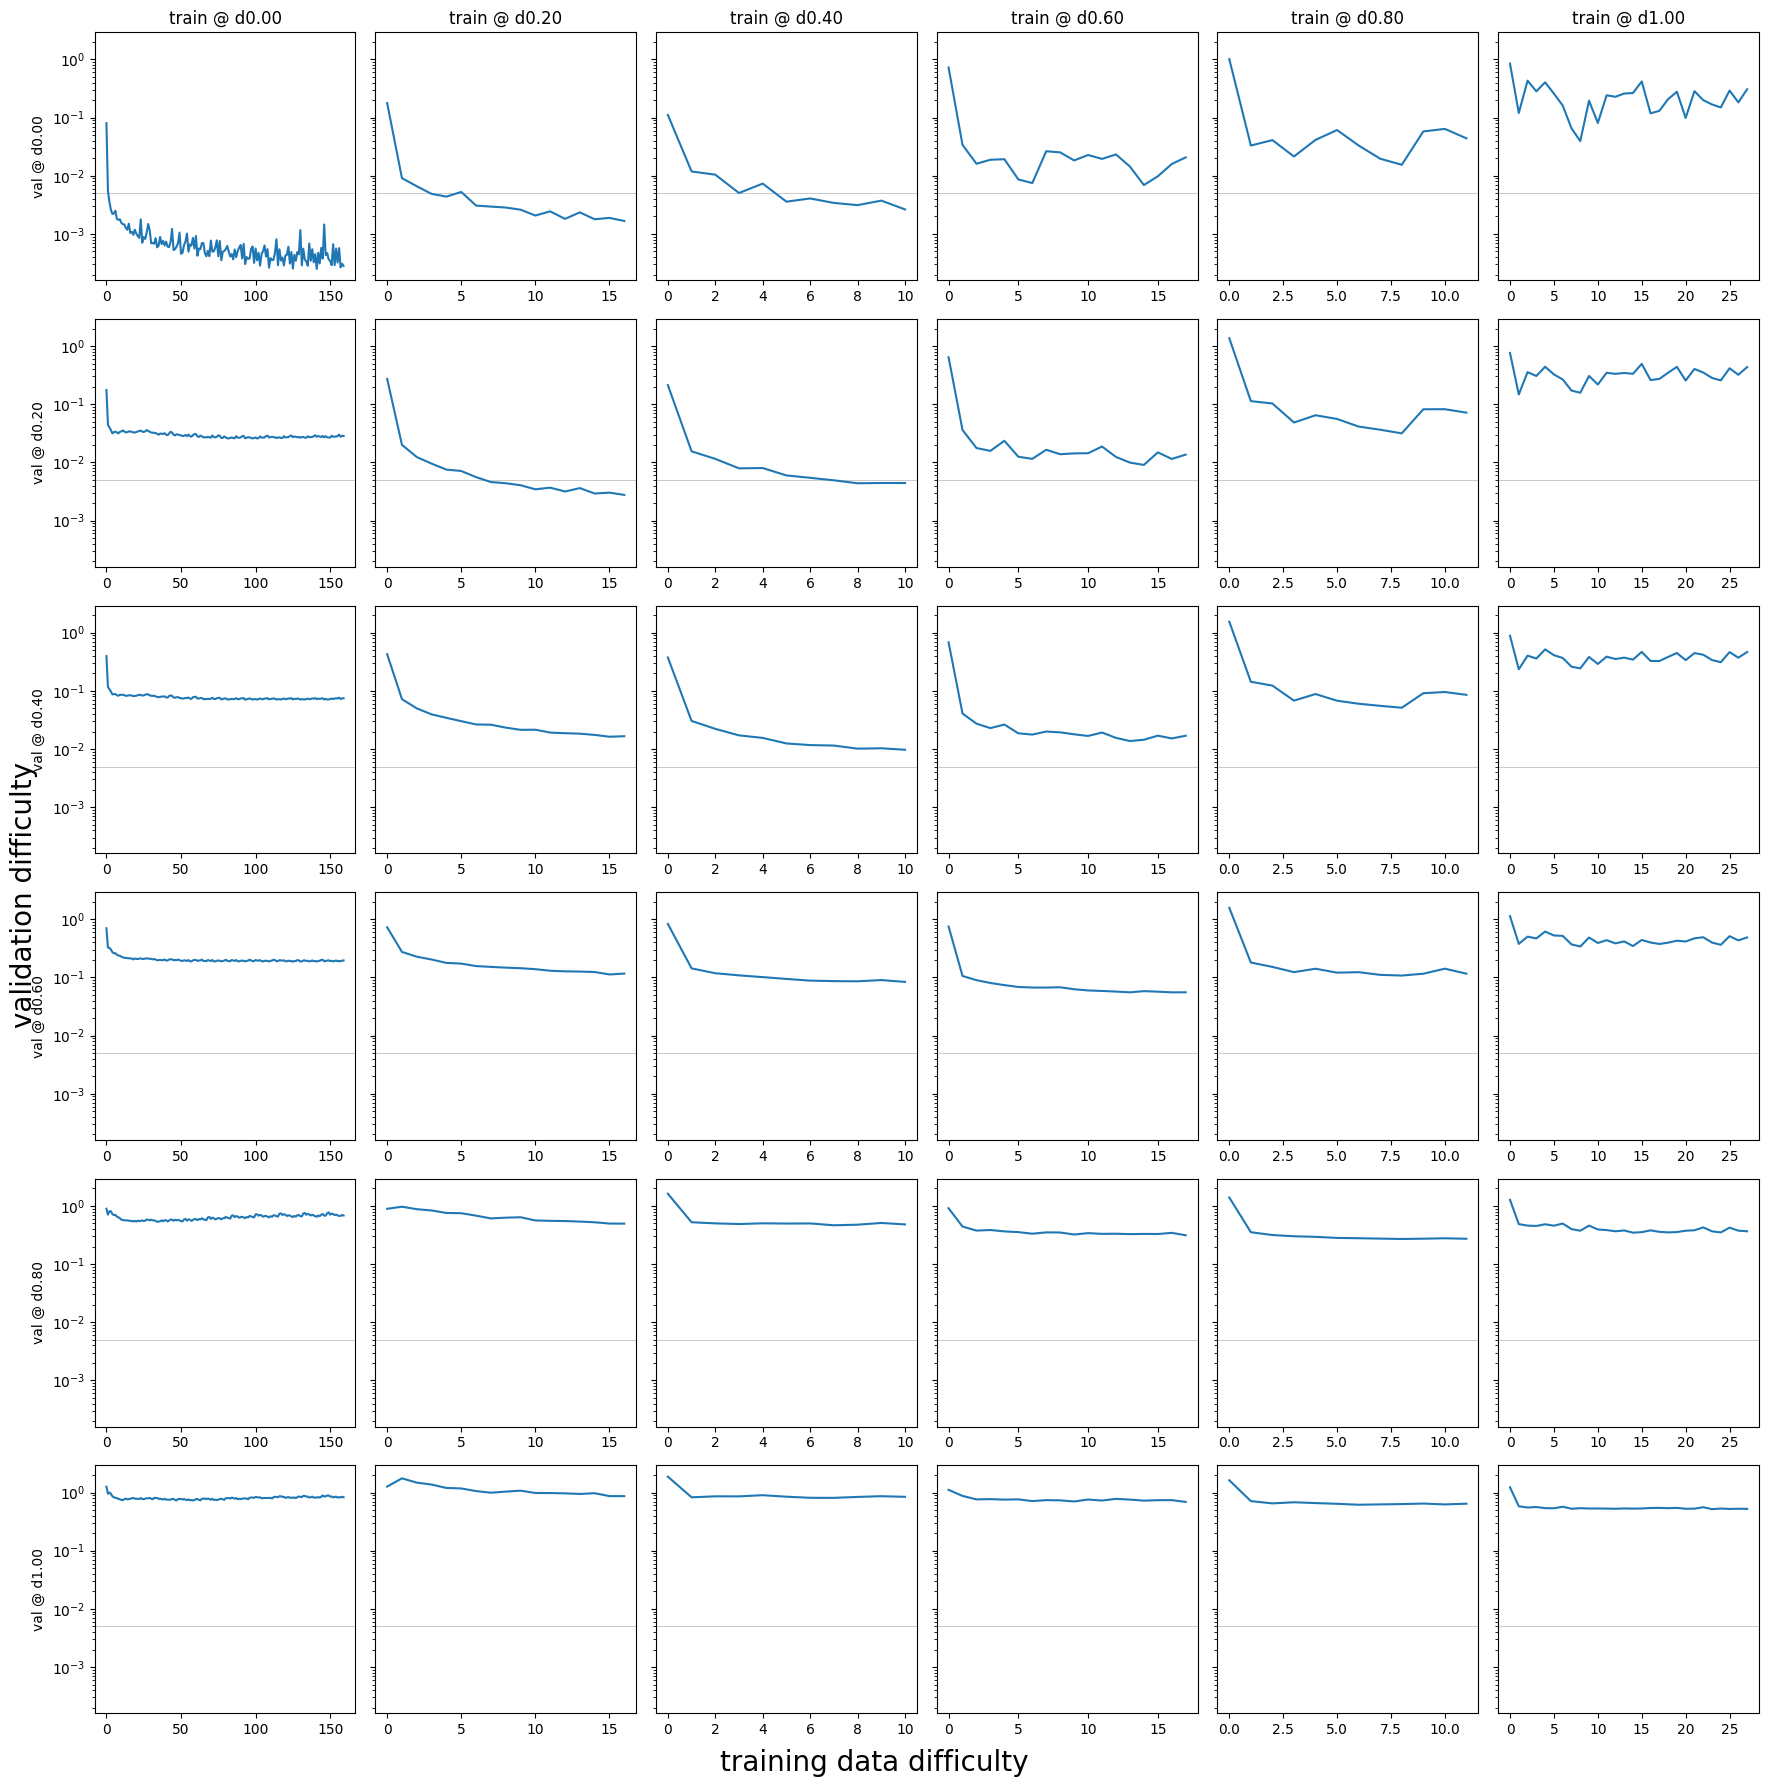

In [6]:
fig, ax = plt.subplots(len(levels), len(levels), figsize=(len(levels)*3, len(levels)*3), sharey=True)
fig.supylabel('validation difficulty', fontsize=20)
fig.supxlabel('training data difficulty', fontsize=20)
for i,level in enumerate(levels):
    history = TrainingHistory(f'{save_paths[level]}/training_history.json')
    history.plot_loss(metrics=['mse'], ax=ax[:, i:i+1])
    ax[i, 0].set_ylabel(f"val @ {level}")
    ax[0, i].set_title(f"train @ {level}")
fig.tight_layout()



In [18]:
from model import PipetteDetectionModel
level = 'd0.40'
model = PipetteDetectionModel(load_model=save_paths[level])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet101v2 (Functional)    (None, 16, 16, 2048)      42626560  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 3)                 6147      
                                                                 
Total params: 42632707 (162.63 MB)
Trainable params: 6147 (24.01 KB)
Non-trainable params: 42626560 (162.61 MB)
_________________________________________________________________
None


1/1 [==============================] - 0s 64ms/step


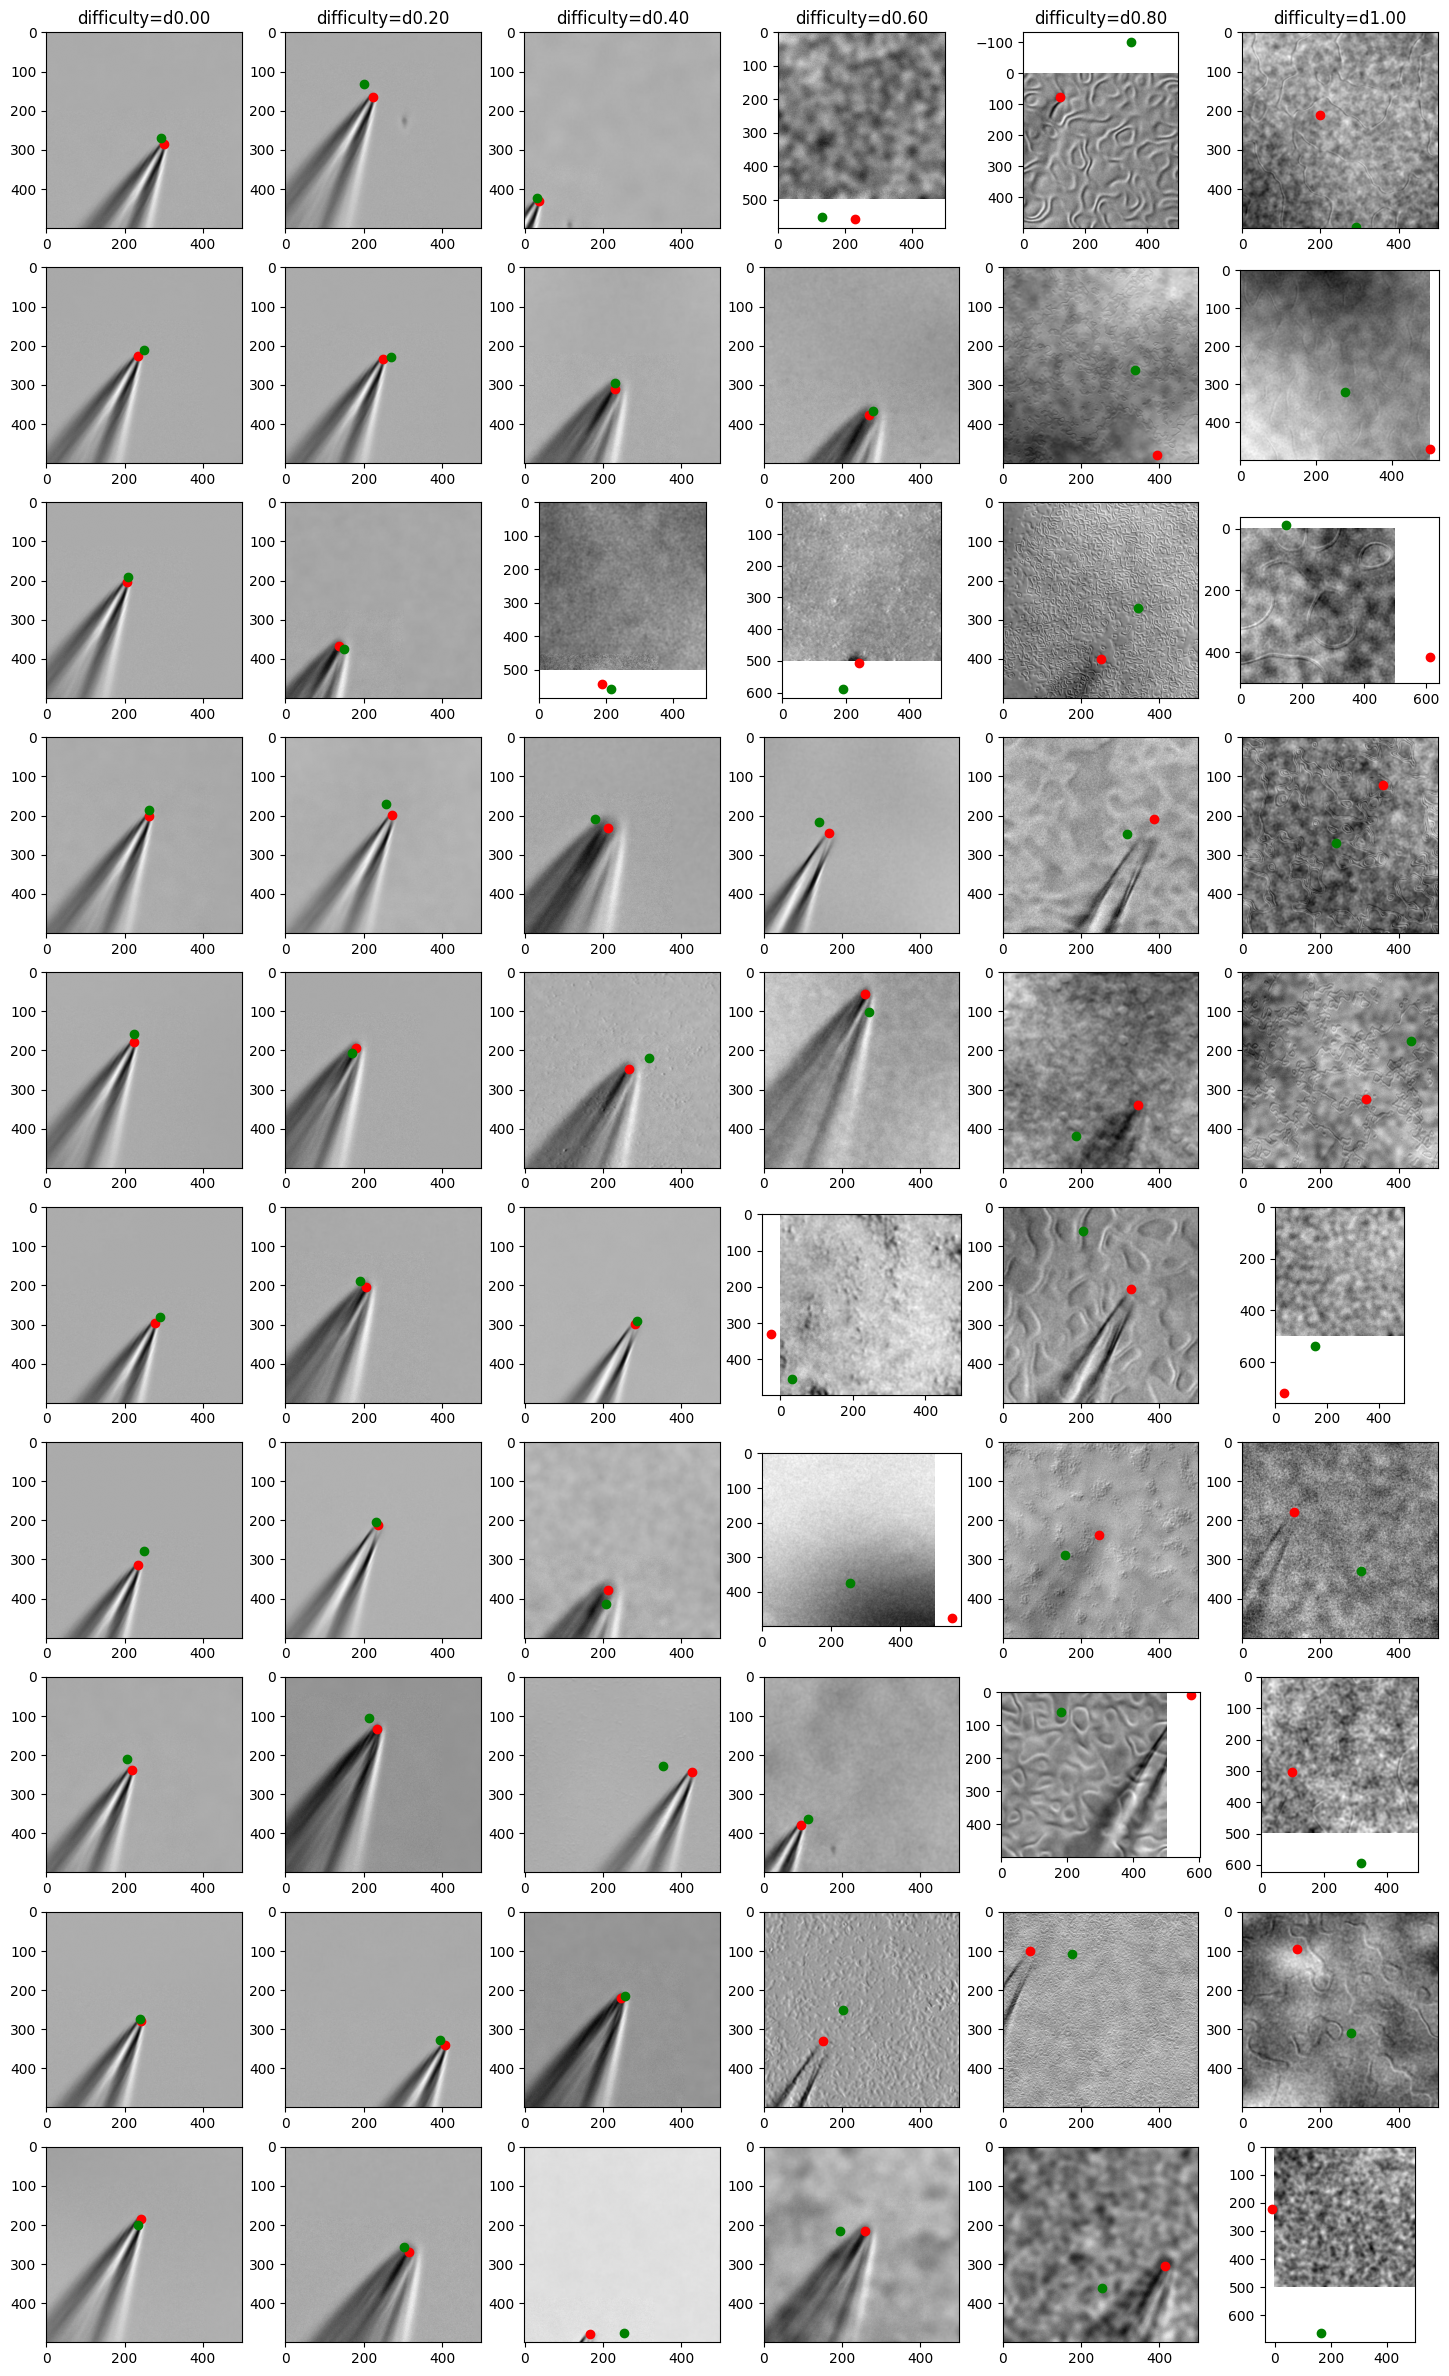

In [19]:
shape = (10, len(levels))
fig, ax = plt.subplots(shape[0], shape[1], figsize=(shape[1]*3, shape[0]*3))

for j, level in enumerate(levels):
    ax[0,j].set_title(f"difficulty={level}")
    image, pip_pos = training_data.levels[level][:shape[0]].get_arrays()
    pip_pos = training_data.output_norm.denormalize(pip_pos)
    pred = training_data.output_norm.denormalize(model.model.predict(image))
    for i in range(shape[0]):
        ax[i,j].imshow(image[i], cmap='gray')
        ax[i,j].scatter(pip_pos[i, 2], pip_pos[i, 1], color='red')
        ax[i,j].scatter(pred[i, 2], pred[i, 1], color='green')
        